# NAB Dataset Exploration
## Project: Real-Time Anomaly Detection MLOps Pipeline
**Dataset:** Numenta Anomaly Benchmark (NAB) — 58 labeled time-series files across 6 categories covering IoT sensors, server metrics, cloud infrastructure, traffic, and social media signals.

**Notebook goals:**
- Load and catalogue all 58 NAB CSV files
- Inspect time ranges, sampling rates, and series lengths
- Visualize anomaly label distribution across NAB categories
- Plot representative time series with anomaly windows highlighted
- Make the dataset selection decision for model training

*Personal portfolio project — not affiliated with the University of Toronto.*

In [1]:
# standard stuff we'll need throughout the notebook
import os
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# cleaner plots
plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="darkgrid")

print("imports done")

imports done


## 1. Load and Catalogue All 58 NAB Files

In [2]:
# NAB data lives in subfolders under data/raw/NAB/data/
# each subfolder is a category, each .csv inside is one time series
NAB_DATA_PATH = Path("../data/raw/NAB/data")

# walk every subfolder and collect file info into a list
catalogue = []

for category_dir in sorted(NAB_DATA_PATH.iterdir()):
    if category_dir.is_dir():
        for csv_file in sorted(category_dir.glob("*.csv")):
            catalogue.append({
                "category": category_dir.name,
                "filename": csv_file.name,
                "filepath": str(csv_file)
            })

catalogue_df = pd.DataFrame(catalogue)

print(f"Total files found: {len(catalogue_df)}")
print(f"\nFiles per category:")
print(catalogue_df["category"].value_counts().to_string())

Total files found: 58

Files per category:
category
realAWSCloudwatch        17
realTweets               10
realKnownCause            7
realTraffic               7
artificialWithAnomaly     6
realAdExchange            6
artificialNoAnomaly       5


## 2. Load All Series and Inspect Structure

In [3]:
# read every file, parse the timestamp, and tag it with category + filename
all_series = []

for _, row in catalogue_df.iterrows():
    df = pd.read_csv(row["filepath"], parse_dates=["timestamp"])
    df["category"] = row["category"]
    df["series_name"] = row["filename"].replace(".csv", "")
    all_series.append(df)

# stack everything into one big dataframe
combined_df = pd.concat(all_series, ignore_index=True)

print(f"Total rows across all series: {len(combined_df):,}")
print(f"\nColumns: {list(combined_df.columns)}")
print(f"\nSample rows:")
combined_df.head(3)

Total rows across all series: 365,558

Columns: ['timestamp', 'value', 'category', 'series_name']

Sample rows:


,timestamp,value,category,series_name
0,2014-04-01 00:00:00,20.0,artificialNoAnomaly,art_daily_no_noise
1,2014-04-01 00:05:00,20.0,artificialNoAnomaly,art_daily_no_noise
2,2014-04-01 00:10:00,20.0,artificialNoAnomaly,art_daily_no_noise


## 3. Per-Series Summary: Length, Time Range, and Sampling Rate

In [4]:
# compute key stats for each of the 58 series
summary_rows = []

for (category, series_name), group in combined_df.groupby(["category", "series_name"]):
    group = group.sort_values("timestamp")
    
    # figure out the most common gap between readings (sampling rate)
    time_diffs = group["timestamp"].diff().dropna()
    median_gap = time_diffs.median()
    
    summary_rows.append({
        "category":       category,
        "series_name":    series_name,
        "n_points":       len(group),
        "start":          group["timestamp"].min(),
        "end":            group["timestamp"].max(),
        "duration_days":  (group["timestamp"].max() - group["timestamp"].min()).days,
        "sampling_rate":  str(median_gap),
        "value_min":      round(group["value"].min(), 2),
        "value_max":      round(group["value"].max(), 2),
        "value_mean":     round(group["value"].mean(), 2),
    })

summary_df = pd.DataFrame(summary_rows)

print(f"Sampling rates found across all series:")
print(summary_df["sampling_rate"].value_counts().to_string())
print(f"\nDuration range: {summary_df['duration_days'].min()} to {summary_df['duration_days'].max()} days")
print(f"Series length range: {summary_df['n_points'].min():,} to {summary_df['n_points'].max():,} points")

Sampling rates found across all series:
sampling_rate
0 days 00:05:00    48
0 days 01:00:00     7
0 days 00:10:00     2
0 days 00:30:00     1

Duration range: 4 to 328 days
Series length range: 1,127 to 22,695 points


## 4. Load Anomaly Labels

In [5]:
# NAB ships anomaly labels as a JSON file with timestamp windows per series
# format: {"filename": [["start_ts", "end_ts"], ...], ...}
labels_path = Path("../data/raw/NAB/labels/combined_windows.json")

with open(labels_path, "r") as f:
    raw_labels = json.load(f)

# flatten into a dataframe — one row per anomaly window
label_rows = []

for series_key, windows in raw_labels.items():
    # key looks like "realAWSCloudwatch/ec2_cpu_utilization_24ae8d.csv"
    category = series_key.split("/")[0]
    filename = series_key.split("/")[1]
    series_name = filename.replace(".csv", "")
    
    for window in windows:
        label_rows.append({
            "category":    category,
            "series_name": series_name,
            "window_start": pd.to_datetime(window[0]),
            "window_end":   pd.to_datetime(window[1])
        })

labels_df = pd.DataFrame(label_rows)

print(f"Total anomaly windows: {len(labels_df)}")
print(f"\nAnomaly windows per category:")
print(labels_df["category"].value_counts().to_string())

Total anomaly windows: 116

Anomaly windows per category:
category
realTweets               33
realAWSCloudwatch        30
realKnownCause           19
realAdExchange           14
realTraffic              14
artificialWithAnomaly     6


## 5. Tag Individual Points as Anomalous

In [6]:
# for each row in combined_df, check if its timestamp falls inside any anomaly window
# we do this series by series to keep it fast

tagged_rows = []

for (category, series_name), group in combined_df.groupby(["category", "series_name"]):
    group = group.copy().sort_values("timestamp")
    
    # default everyone to normal
    group["is_anomaly"] = 0
    
    # find anomaly windows for this specific series
    windows = labels_df[
        (labels_df["category"] == category) &
        (labels_df["series_name"] == series_name)
    ]
    
    # stamp any point that falls inside a window as anomalous
    for _, window in windows.iterrows():
        mask = (
            (group["timestamp"] >= window["window_start"]) &
            (group["timestamp"] <= window["window_end"])
        )
        group.loc[mask, "is_anomaly"] = 1
    
    tagged_rows.append(group)

tagged_df = pd.concat(tagged_rows, ignore_index=True)

# quick sanity check
total_points    = len(tagged_df)
anomaly_points  = tagged_df["is_anomaly"].sum()
normal_points   = total_points - anomaly_points

print(f"Total points:   {total_points:,}")
print(f"Normal points:  {normal_points:,}  ({100 * normal_points / total_points:.2f}%)")
print(f"Anomaly points: {anomaly_points:,}  ({100 * anomaly_points / total_points:.2f}%)")

Total points:   365,558
Normal points:  332,063  (90.84%)
Anomaly points: 33,495  (9.16%)


## 6. Anomaly Distribution Across Categories

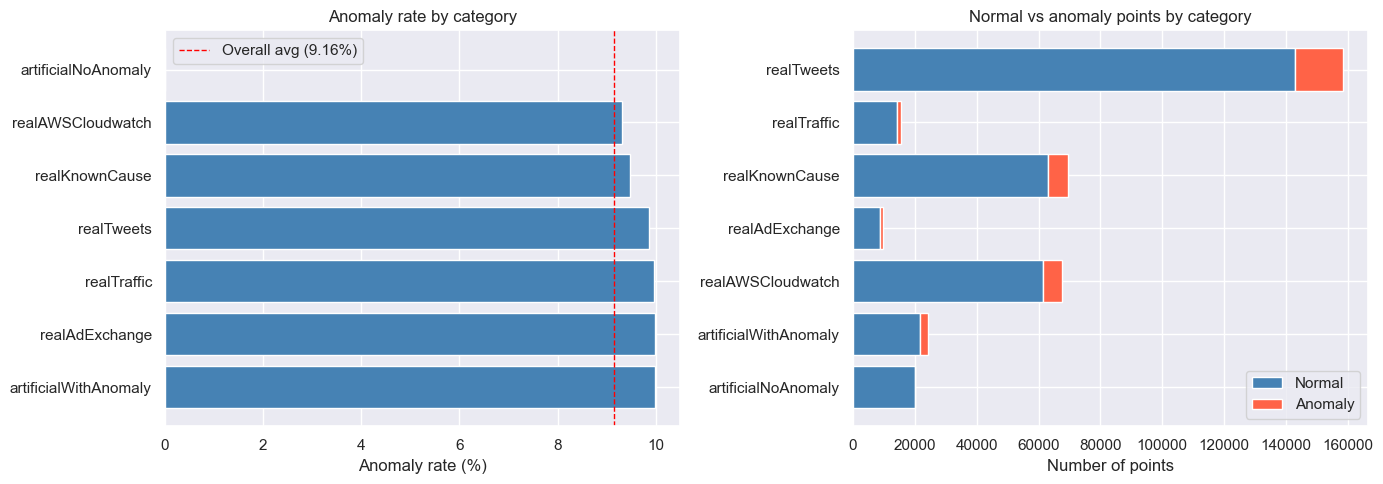

chart saved


In [7]:
# compute anomaly rate per category for the bar chart
category_stats = (
    tagged_df.groupby("category")["is_anomaly"]
    .agg(total="count", anomalies="sum")
    .assign(anomaly_rate=lambda x: 100 * x["anomalies"] / x["total"])
    .sort_values("anomaly_rate", ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: anomaly rate % per category
axes[0].barh(category_stats["category"], category_stats["anomaly_rate"], color="steelblue")
axes[0].set_xlabel("Anomaly rate (%)")
axes[0].set_title("Anomaly rate by category")
axes[0].axvline(x=9.16, color="red", linestyle="--", linewidth=1, label="Overall avg (9.16%)")
axes[0].legend()

# right: total anomaly points vs normal points per category
category_stats2 = (
    tagged_df.groupby("category")["is_anomaly"]
    .agg(normal=lambda x: (x == 0).sum(), anomalies="sum")
    .reset_index()
)

axes[1].barh(category_stats2["category"], category_stats2["normal"], label="Normal", color="steelblue")
axes[1].barh(category_stats2["category"], category_stats2["anomalies"],
             left=category_stats2["normal"], label="Anomaly", color="tomato")
axes[1].set_xlabel("Number of points")
axes[1].set_title("Normal vs anomaly points by category")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/category_anomaly_distribution.png", dpi=100, bbox_inches="tight")
plt.show()
print("chart saved")

## 7. Representative Time Series with Anomaly Windows

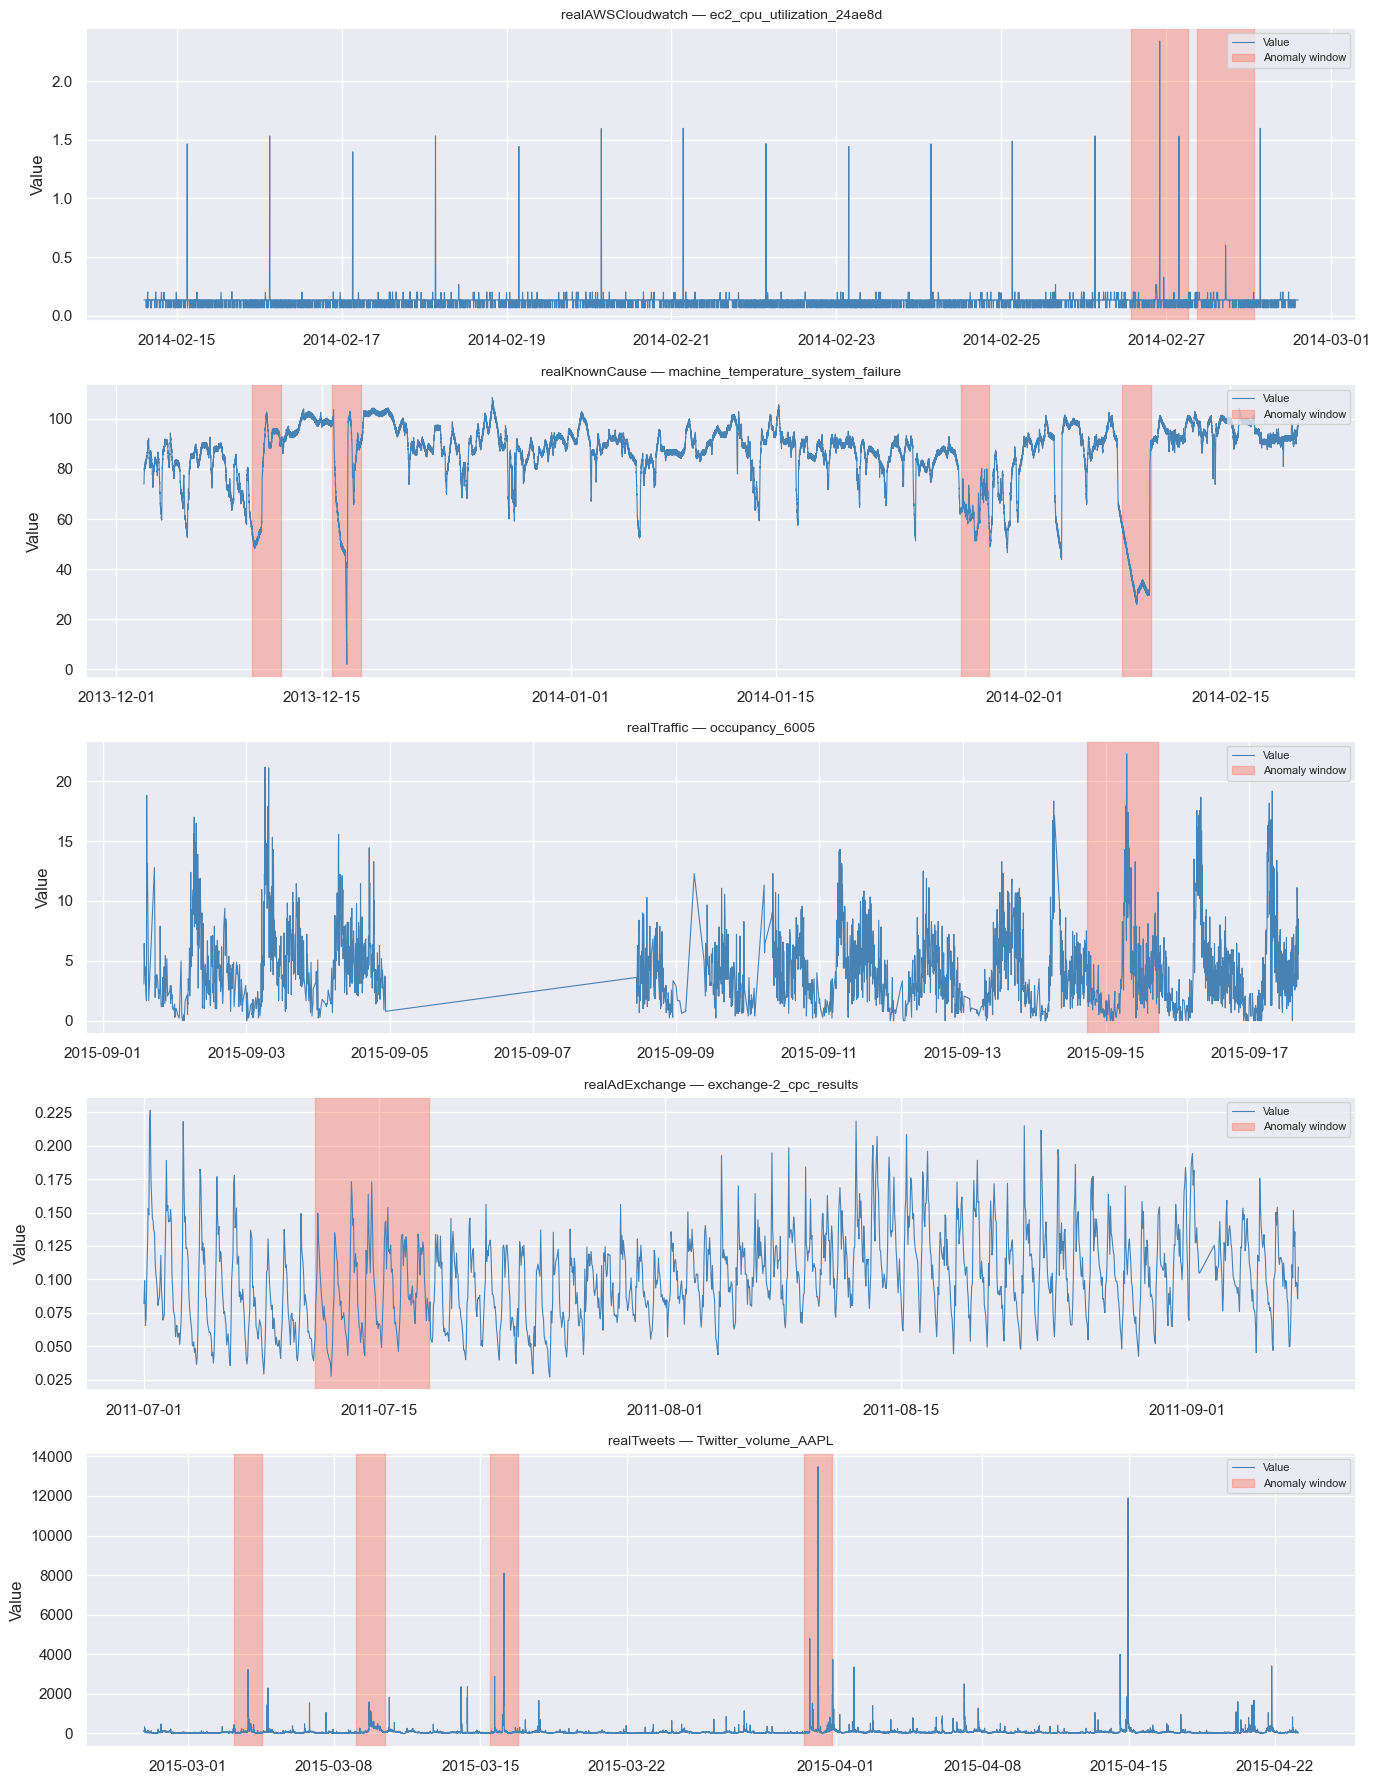

chart saved


In [8]:
# pick one representative series from each real-world category
representatives = {
    "realAWSCloudwatch": "ec2_cpu_utilization_24ae8d",
    "realKnownCause":    "machine_temperature_system_failure",
    "realTraffic":       "occupancy_6005",
    "realAdExchange":    "exchange-2_cpc_results",
    "realTweets":        "Twitter_volume_AAPL",
}

fig, axes = plt.subplots(len(representatives), 1, figsize=(14, 18))

for ax, (category, series_name) in zip(axes, representatives.items()):
    # pull the series data
    series_data = tagged_df[
        (tagged_df["category"] == category) &
        (tagged_df["series_name"] == series_name)
    ].sort_values("timestamp")

    # plot the value line
    ax.plot(series_data["timestamp"], series_data["value"],
            linewidth=0.8, color="steelblue", label="Value")

    # shade every anomaly window as a red band
    windows = labels_df[
        (labels_df["category"] == category) &
        (labels_df["series_name"] == series_name)
    ]
    for _, window in windows.iterrows():
        ax.axvspan(window["window_start"], window["window_end"],
                   alpha=0.35, color="tomato", label="Anomaly window")

    # clean up the legend (avoid duplicate labels)
    handles, lbls = ax.get_legend_handles_labels()
    by_label = dict(zip(lbls, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=8)

    ax.set_title(f"{category} — {series_name}", fontsize=10)
    ax.set_ylabel("Value")
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("../data/processed/representative_series.png", dpi=100, bbox_inches="tight")
plt.show()
print("chart saved")

## 8. Dataset Selection for Model Training

In [9]:
# review sampling rates per category to confirm training set selection
sampling_by_category = (
    tagged_df.groupby(["category", "series_name", "timestamp"])
    .first()
    .reset_index()
    .groupby(["category", "series_name"])
    .apply(lambda g: g.sort_values("timestamp")["timestamp"].diff().dropna().median())
    .reset_index()
    .rename(columns={0: "median_gap"})
    .groupby("category")["median_gap"]
    .agg(["first", "nunique"])
    .rename(columns={"first": "sampling_rate", "nunique": "n_unique_rates"})
)

print("Sampling rate consistency per category:")
print(sampling_by_category.to_string())

print("""
--- Training Set Decision ---

Selected categories for LSTM autoencoder training:
  1. realAWSCloudwatch  — 17 series, 5-min intervals, cloud infrastructure metrics
  2. realKnownCause     —  7 series, 5-min intervals, ground-truth labeled anomalies
  3. artificialWithAnomaly — 6 series, 5-min intervals, clean synthetic anomalies

Excluded categories:
  - realTweets         — hourly intervals, social media (different domain)
  - realTraffic        — mixed intervals, short series
  - realAdExchange     — 10-min intervals, financial domain
  - artificialNoAnomaly — no anomaly labels (used only for unsupervised pretraining)

Rationale:
  - All selected series use 5-minute intervals (consistent window sizing)
  - realAWSCloudwatch + realKnownCause mirror IoT/infrastructure monitoring
    use cases directly relevant to Nokia, Ericsson, and Qualcomm portfolios
  - 30 series total gives sufficient variety without domain mixing
  - LSTM autoencoder trains on normal data only — anomaly labels used
    only for evaluation, not training
""")

Sampling rate consistency per category:
                        sampling_rate  n_unique_rates
category                                             
artificialNoAnomaly   0 days 00:05:00               1
artificialWithAnomaly 0 days 00:05:00               1
realAWSCloudwatch     0 days 00:05:00               1
realAdExchange        0 days 01:00:00               1
realKnownCause        0 days 01:00:00               3
realTraffic           0 days 00:10:00               2
realTweets            0 days 00:05:00               1

--- Training Set Decision ---

Selected categories for LSTM autoencoder training:
  1. realAWSCloudwatch  — 17 series, 5-min intervals, cloud infrastructure metrics
  2. realKnownCause     —  7 series, 5-min intervals, ground-truth labeled anomalies
  3. artificialWithAnomaly — 6 series, 5-min intervals, clean synthetic anomalies

Excluded categories:
  - realTweets         — hourly intervals, social media (different domain)
  - realTraffic        — mixed intervals, sh

C:\Users\nabee\AppData\Local\Temp\ipykernel_11308\2044244248.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values("timestamp")["timestamp"].diff().dropna().median())


## 9. Revised Dataset Selection Based on Actual Sampling Rates

In [10]:
# corrected training set based on actual sampling rate output above
print("""
--- Revised Training Set Decision ---

5-minute series (consistent, suitable for LSTM windowing):
  - artificialNoAnomaly    5 series  — 5-min  — no anomalies (normal-only pretraining)
  - artificialWithAnomaly  6 series  — 5-min  — synthetic injected anomalies
  - realAWSCloudwatch     17 series  — 5-min  — cloud CPU/network/disk metrics
  - realTweets            10 series  — 5-min  — Twitter volume per stock ticker

Excluded (inconsistent or non-5-min sampling):
  - realKnownCause   — median 1hr, 3 unique rates (mixed, unreliable windowing)
  - realTraffic      — 10-min median, 2 unique rates (mixed)
  - realAdExchange   — 1-hour intervals (different temporal resolution)

Final training set: 38 series, all at 5-minute intervals
  - Train LSTM autoencoder on normal segments only
  - Evaluate reconstruction error against anomaly labels
  - realTweets included — volume spikes are valid IoT-adjacent signals
    and add domain diversity to the training set
""")

# save the selected subset for use in Notebook 02
selected_categories = [
    "artificialNoAnomaly",
    "artificialWithAnomaly",
    "realAWSCloudwatch",
    "realTweets"
]

selected_df = tagged_df[tagged_df["category"].isin(selected_categories)].copy()

print(f"Selected subset shape: {selected_df.shape}")
print(f"Anomaly rate in selected subset: {100 * selected_df['is_anomaly'].mean():.2f}%")
print(f"\nSeries count per category:")
print(selected_df.groupby("category")["series_name"].nunique().to_string())


--- Revised Training Set Decision ---

5-minute series (consistent, suitable for LSTM windowing):
  - artificialNoAnomaly    5 series  — 5-min  — no anomalies (normal-only pretraining)
  - artificialWithAnomaly  6 series  — 5-min  — synthetic injected anomalies
  - realAWSCloudwatch     17 series  — 5-min  — cloud CPU/network/disk metrics
  - realTweets            10 series  — 5-min  — Twitter volume per stock ticker

Excluded (inconsistent or non-5-min sampling):
  - realKnownCause   — median 1hr, 3 unique rates (mixed, unreliable windowing)
  - realTraffic      — 10-min median, 2 unique rates (mixed)
  - realAdExchange   — 1-hour intervals (different temporal resolution)

Final training set: 38 series, all at 5-minute intervals
  - Train LSTM autoencoder on normal segments only
  - Evaluate reconstruction error against anomaly labels
  - realTweets included — volume spikes are valid IoT-adjacent signals
    and add domain diversity to the training set

Selected subset shape: (270723

## 10. Save Selected Subset and Summary

In [11]:
import os

# make sure the processed folder exists
os.makedirs("../data/processed", exist_ok=True)

# save the selected subset as parquet (faster and smaller than CSV)
selected_df.to_parquet("../data/processed/selected_series.parquet", index=False)

# save the summary table for reference
summary_selected = summary_df[summary_df["category"].isin(selected_categories)].copy()
summary_selected.to_csv("../data/processed/selected_series_summary.csv", index=False)

# save labels for the selected categories too
labels_selected = labels_df[labels_df["category"].isin(selected_categories)].copy()
labels_selected.to_parquet("../data/processed/selected_labels.parquet", index=False)

print("Saved files:")
print("  data/processed/selected_series.parquet")
print("  data/processed/selected_series_summary.csv")
print("  data/processed/selected_labels.parquet")
print(f"\nParquet file size: {os.path.getsize('../data/processed/selected_series.parquet') / 1024:.1f} KB")

Saved files:
  data/processed/selected_series.parquet
  data/processed/selected_series_summary.csv
  data/processed/selected_labels.parquet

Parquet file size: 1465.9 KB


## Summary

### What we found
- NAB contains 58 labeled time-series files across 7 categories and 365,558 total data points
- Overall anomaly rate is 9.16% — a healthy imbalance for unsupervised autoencoder training
- Sampling rates are inconsistent across categories: 5-min, 10-min, 30-min, and 1-hour series exist
- 4 categories use consistent 5-minute intervals: `artificialNoAnomaly`, `artificialWithAnomaly`, `realAWSCloudwatch`, `realTweets`

### Dataset selection
- **38 series selected** (270,723 points, 9.01% anomaly rate) — all at 5-minute intervals
- LSTM autoencoder will train on **normal segments only** — anomaly labels reserved for evaluation
- `realAWSCloudwatch` is the anchor category — directly mirrors cloud infrastructure monitoring at Nokia, Ericsson, and Qualcomm

### Outputs saved
- `data/processed/selected_series.parquet` — tagged time-series data for 38 selected series
- `data/processed/selected_labels.parquet` — anomaly windows for selected series
- `data/processed/selected_series_summary.csv` — per-series metadata table

### Next: Notebook 02 — Feature Engineering
- Load `selected_series.parquet`
- Design sliding window parameters (window size, stride, normalization strategy)
- Compute rolling features: mean, std, rate of change, lag features
- Write feature tables to DuckDB via dbt
- Produce train/val/test splits stratified by series